# DTCG Datacubes

In [1]:
import dtcg
import dtcg.integration.oggm_bindings as oggm_bindings
import oggm
from oggm.core import massbalance
import json
from pathlib import Path
from datetime import datetime, date, timezone, timedelta

import numpy as np
import xarray as xr

# Setup OGGM

In [2]:
base_url = "https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands_w_data/W5E5/per_glacier/"
output_dir = Path("./static/data/datacube_gen/")

In [56]:
def load_ids_from_json(path: str) -> list:
    with open(path) as file:
        rgi_ids = json.load(file)
    assert isinstance(rgi_ids, list)
    return rgi_ids


iceland_ids = load_ids_from_json(path=output_dir / "vatnajokull_rgi_ids.json")
alpine_ids = load_ids_from_json(path=output_dir / "oetztal_rgi_ids.json")
rgi_ids = set(alpine_ids)
# assert len(rgi_ids) == len(iceland_ids + alpine_ids)

In [4]:
binder = dtcg.integration.oggm_bindings.BindingsCryotempo()

In [5]:
from oggm import workflow
from oggm.shop import w5e5


def get_data(rgi_ids: list):
    """Get dashboard data.

    Returns
    -------
    tuple
        Glacier directory, EOLIS-enhanced gridded data, and specific mass balance.
    """
    binder.init_oggm(dirname="gen-outlines", reset=True)
    gdirs = binder.get_glacier_directories(
        rgi_ids=rgi_ids, from_prepro_level=4, prepro_border=80
    )
    print("Fetching OGGM data from shop...")

    binder.get_glacier_data(gdirs=gdirs)
    # workflow.execute_entity_task(
    #         gdirs=gdirs, task=w5e5.process_w5e5_data, daily=True
    #     )
    for gdir in gdirs:
        binder.set_flowlines(gdir)
    return gdirs

In [6]:
def export_outlines(gdir, save_path):
    glacier_outlines_gdf = gdir.read_shapefile("outlines")
    glacier_outlines_gdf.to_feather(path=save_path / "outlines.shp")

def set_save_folder(rgi_id, folder="../ext/data/l2_precompute/"):
    save_folder = Path(folder)
    assert save_folder.is_dir()
    save_path = save_folder / f"{rgi_id}/"
    Path(save_path).mkdir(parents=True, exist_ok=True)
    assert save_path.is_dir()
    return save_path


In [7]:
# rgi_ids = ["RGI60-06.00377"]
data = {}
gdirs = get_data(rgi_ids)

Fetching OGGM data from shop...


In [8]:
for gdir in gdirs:
    data[gdir.rgi_id] = {}
    output_path = set_save_folder(rgi_id=gdir.rgi_id, folder=output_dir)
    export_outlines(gdir=gdir, save_path=output_path)

In [9]:
import geopandas as gpd
import pandas as pd
# rgi_ids = set(list(iceland_glaciers.values()))# + list(alpine_glaciers.values()))
geometries = {}
for rgi_id in rgi_ids:
    save_path= Path(output_dir / rgi_id)
    if save_path.exists():
        geometries[f"{rgi_id}"] = gpd.read_feather(save_path/"outlines.shp").to_crs(4326)

df = gpd.GeoDataFrame(pd.concat(geometries.values(), ignore_index=True), crs=list(geometries.values())[0].crs)
df.head()

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name,check_geom,geometry
0,RGI60-11.00853,G011073E46828N,20030799,20030999,11.0731,46.8283,11,1,0.112,2813,...,574,0,0,0,0,9,9,None,None,"POLYGON ((11.07582 46.82848, 11.07584 46.82825..."
1,RGI60-11.00392,G011110E47046N,20030799,20030999,11.1096,47.0458,11,1,1.397,2760,...,2166,0,0,0,0,9,9,None,None,"POLYGON ((11.10425 47.05175, 11.10504 47.05197..."
2,RGI60-11.00556,G011079E46987N,20030799,20030999,11.079,46.9872,11,1,0.015,3255,...,135,0,0,0,0,9,9,None,None,"POLYGON ((11.0796 46.98665, 11.07921 46.98666,..."
3,RGI60-11.00890,G010959E46817N,20030799,20030999,10.9589,46.817,11,1,0.265,3032,...,596,0,0,0,0,9,9,None,None,"POLYGON ((10.95589 46.81713, 10.95625 46.81712..."
4,RGI60-11.00948,G011030E46794N,20030799,20030999,11.0302,46.794,11,1,0.063,2886,...,450,0,0,0,0,9,9,None,None,"POLYGON ((11.03123 46.7926, 11.03084 46.79261,..."


In [10]:
df = df[["RGIId", "GLIMSId","BgnDate", "EndDate", "CenLon","CenLat", "O1Region", "O2Region", "Area", "Zmax", "Zmin", "Name", "geometry"]]
df.to_feather(output_dir/f"RGI60-{df["O1Region"][0].zfill(2)}/glacier_outlines.shp")
df

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmax,Zmin,Name,geometry
0,RGI60-11.00853,G011073E46828N,20030799,20030999,11.0731,46.8283,11,1,0.112,3094,2813,None,"POLYGON ((11.07582 46.82848, 11.07584 46.82825..."
1,RGI60-11.00392,G011110E47046N,20030799,20030999,11.1096,47.0458,11,1,1.397,3430,2760,None,"POLYGON ((11.10425 47.05175, 11.10504 47.05197..."
2,RGI60-11.00556,G011079E46987N,20030799,20030999,11.079,46.9872,11,1,0.015,3311,3255,None,"POLYGON ((11.0796 46.98665, 11.07921 46.98666,..."
3,RGI60-11.00890,G010959E46817N,20030799,20030999,10.9589,46.817,11,1,0.265,3343,3032,None,"POLYGON ((10.95589 46.81713, 10.95625 46.81712..."
4,RGI60-11.00948,G011030E46794N,20030799,20030999,11.0302,46.794,11,1,0.063,3022,2886,None,"POLYGON ((11.03123 46.7926, 11.03084 46.79261,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,RGI60-11.00957,G010805E46780N,20030799,20030999,10.8054,46.7801,11,1,3.085,3396,2669,None,"POLYGON ((10.82406 46.78091, 10.82511 46.78075..."
146,RGI60-11.00333,G011066E47077N,20030799,20030999,11.0658,47.0773,11,1,0.019,2836,2731,None,"POLYGON ((11.06492 47.07655, 11.06493 47.07682..."
147,RGI60-11.00650,G011085E46938N,20030799,20030999,11.0848,46.9375,11,1,0.022,3026,2940,None,"POLYGON ((11.08556 46.93687, 11.08516 46.93688..."
148,RGI60-11.00501,G011056E47004N,20030799,20030999,11.056,47.0043,11,1,0.262,3183,2756,None,"POLYGON ((11.05646 47.0003, 11.05606 47.00031,..."


In [11]:
outlines = gpd.read_feather(output_dir/"RGI60-11/glacier_outlines.shp")
outlines

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmax,Zmin,Name,geometry
0,RGI60-11.00853,G011073E46828N,20030799,20030999,11.0731,46.8283,11,1,0.112,3094,2813,None,"POLYGON ((11.07582 46.82848, 11.07584 46.82825..."
1,RGI60-11.00392,G011110E47046N,20030799,20030999,11.1096,47.0458,11,1,1.397,3430,2760,None,"POLYGON ((11.10425 47.05175, 11.10504 47.05197..."
2,RGI60-11.00556,G011079E46987N,20030799,20030999,11.079,46.9872,11,1,0.015,3311,3255,None,"POLYGON ((11.0796 46.98665, 11.07921 46.98666,..."
3,RGI60-11.00890,G010959E46817N,20030799,20030999,10.9589,46.817,11,1,0.265,3343,3032,None,"POLYGON ((10.95589 46.81713, 10.95625 46.81712..."
4,RGI60-11.00948,G011030E46794N,20030799,20030999,11.0302,46.794,11,1,0.063,3022,2886,None,"POLYGON ((11.03123 46.7926, 11.03084 46.79261,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,RGI60-11.00957,G010805E46780N,20030799,20030999,10.8054,46.7801,11,1,3.085,3396,2669,None,"POLYGON ((10.82406 46.78091, 10.82511 46.78075..."
146,RGI60-11.00333,G011066E47077N,20030799,20030999,11.0658,47.0773,11,1,0.019,2836,2731,None,"POLYGON ((11.06492 47.07655, 11.06493 47.07682..."
147,RGI60-11.00650,G011085E46938N,20030799,20030999,11.0848,46.9375,11,1,0.022,3026,2940,None,"POLYGON ((11.08556 46.93687, 11.08516 46.93688..."
148,RGI60-11.00501,G011056E47004N,20030799,20030999,11.056,47.0043,11,1,0.262,3183,2756,None,"POLYGON ((11.05646 47.0003, 11.05606 47.00031,..."


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
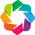

:Overlay
   .Polygons.I :Polygons   [Longitude,Latitude]   (RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmax,Zmin,Name)
   .WMTS.I     :WMTS   [Longitude,Latitude]

In [12]:
import dtcg.interface.plotting as dtcg_plotting
import geoviews as gv
graph_artist = dtcg_plotting.BokehMap()
overlay = gv.Polygons(outlines).opts(
    fill_color=graph_artist.palette[2],
    line_color="black",
    line_width=0.8,
    fill_alpha=0.4,
    color_index=None,
) * gv.tile_sources.EsriWorldTopo()
figure= overlay
figure

In [ ]:
rgi_ids = set(alpine_ids+iceland_ids)
gdirs = get_data(rgi_ids)




KeyboardInterrupt: 

In [67]:
def get_glacier_df(rgi_ids, output_dir):
    geometries={}
    for rgi_id in rgi_ids:
        save_path= Path(output_dir / rgi_id)
        if save_path.exists():
            geometries[f"{rgi_id}"] = gpd.read_feather(save_path/"outlines.shp").to_crs(4326)

    df = gpd.GeoDataFrame(pd.concat(geometries.values(), ignore_index=True), crs=list(geometries.values())[0].crs)
    df['Name'] = np.where(df['Name'].isna() , df['RGIId'], df['Name'])

    return df

In [68]:
def export_region_list(data, save_path="glacier_index"):
    # save_path = set_save_folder(rgi_id=save_path)
    with open(save_path / "glacier_index.json", mode="w", encoding="utf-8") as file:
        json.dump(data, file)


In [70]:
subset = ["RGIId", "Name", "O1Region", "O2Region"]
region_list = {}
alpine_glaciers = get_glacier_df(rgi_ids=alpine_ids, output_dir=output_dir)
iceland_glaciers = get_glacier_df(rgi_ids=iceland_ids, output_dir=output_dir)

region_list["Central Europe"] = alpine_glaciers[subset].set_index("RGIId").to_dict(orient="index")
region_list["Iceland"] = iceland_glaciers[subset].set_index("RGIId").to_dict(orient="index")
export_region_list(region_list,save_path=output_dir)

In [66]:
Path(output_dir/"RGI60-11").is_dir()

True